# 📊 Segmentação Estratégica de Clientes com KMeans

Projeto de Data Science focado na identificação de perfis distintos de clientes
com base em idade e renda, utilizando técnicas de clustering não supervisionado.

Objetivo: gerar insights estratégicos para apoio à tomada de decisão em marketing e segmentação.

## 🎯 Problema de Negócio

Empresas frequentemente possuem bases de clientes heterogêneas.
Sem segmentação adequada, estratégias de marketing tornam-se genéricas e menos eficientes.

Pergunta central:

É possível identificar grupos distintos de clientes com base em idade e renda,
de forma a apoiar decisões estratégicas?

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 📂 Carregamento dos Dados

In [58]:
df = pd.read_csv("../data/segmentation data.csv")
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


O dataset contém informações demográficas básicas dos clientes,
incluindo idade e renda anual.

## 🔎 Análise Exploratória

- Estatística descritiva

In [59]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


- Distribuição de idade

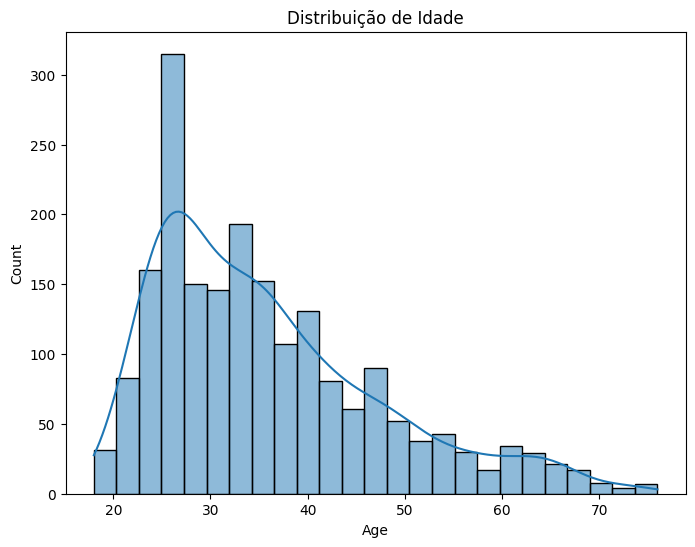

In [60]:
plt.figure(figsize=(8,6))
sns.histplot(df["Age"], kde=True)
plt.title("Distribuição de Idade")
plt.show()

- Distribuição de renda

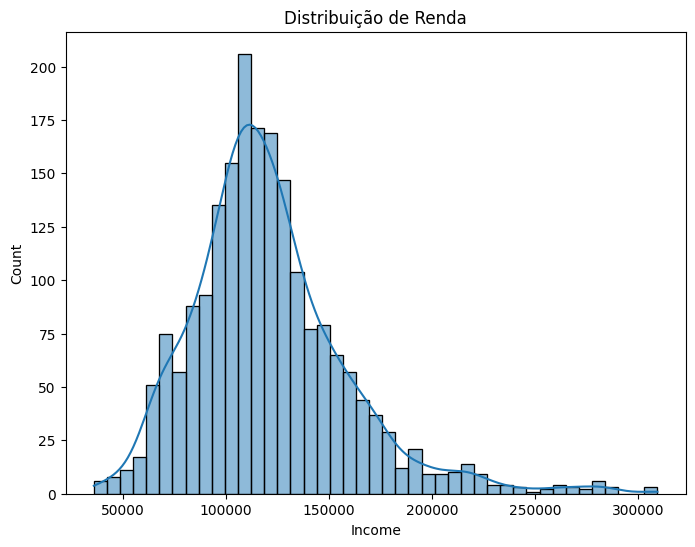

In [61]:
plt.figure(figsize=(8,6))
sns.histplot(df["Income"], kde=True)
plt.title("Distribuição de Renda")
plt.show()

- Correlação

Text(0.5, 1.0, 'Matriz de Correlação')

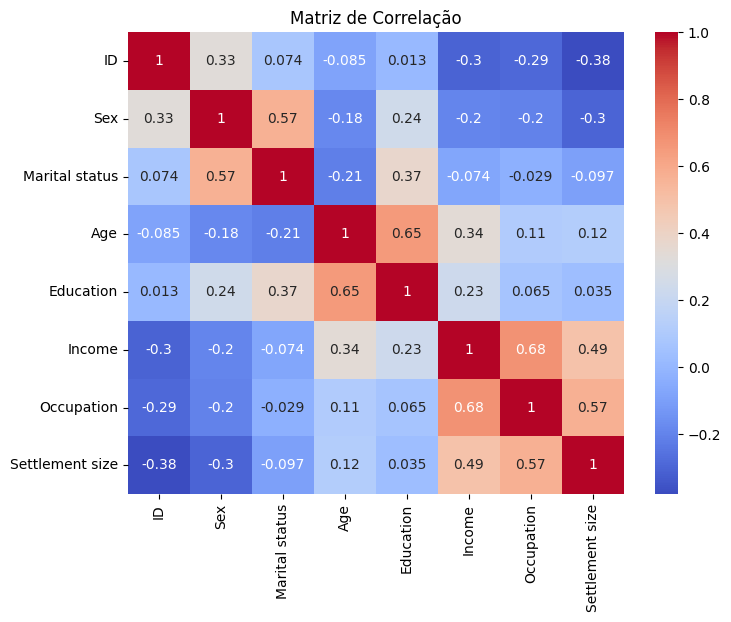

In [62]:
plt.figure(figsize=(8,6))
corr_matriz = df.corr()
sns.heatmap(corr_matriz, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")

## ⚙️ Padronização das Variáveis

O algoritmo KMeans é sensível à escala das variáveis.
Por isso, aplicamos padronização.

In [63]:
features = ["Age", "Income"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

## 📉 Método do Cotovelo

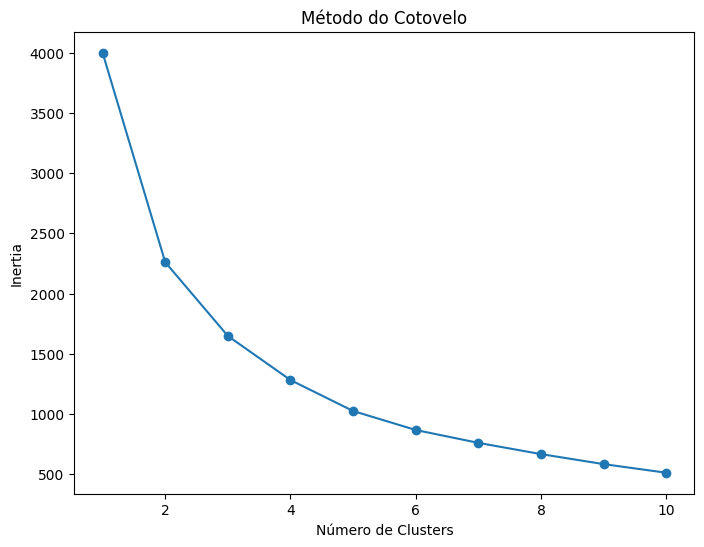

In [64]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.show()

## 🤖 Aplicação do KMeans

In [65]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

## 📊 Avaliação com Silhouette Score

In [66]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.4426815979255089


## 📍 Visualização dos Grupos

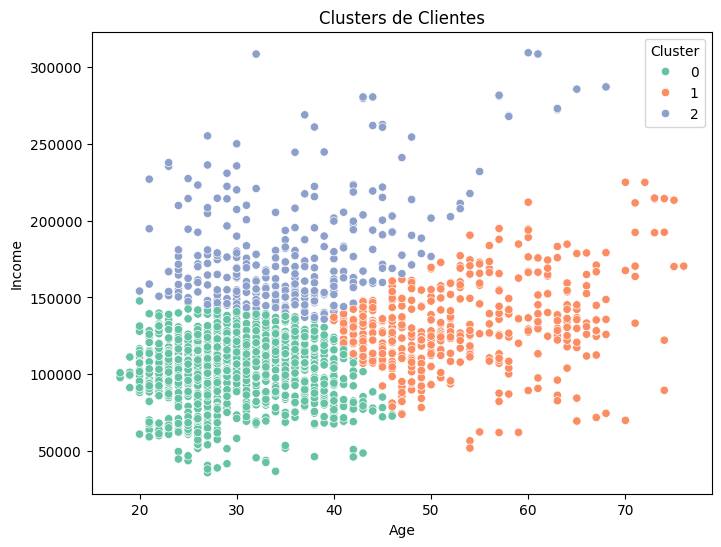

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Age", y="Income", hue="Cluster", palette="Set2")
plt.title("Clusters de Clientes")
plt.show()

## 🧠 Interpretação dos Perfis

In [68]:
cluster_means = df.groupby("Cluster")[["Age", "Income"]].mean()
cluster_means

,Age,Income
Cluster,,
0,29.739837,102119.035772
1,53.047297,131340.977477
2,35.843558,177874.325153


Com base nas médias observadas, cada cluster foi interpretado estrategicamente,
permitindo transformar agrupamentos matemáticos em perfis de negócio acionáveis.

Cluster 0 – Jovens com renda média  
Cluster 1 – Adultos com alta renda  
Cluster 2 – Perfil mais maduro com renda estável  

Cada perfil pode receber estratégias de marketing distintas.

# 📌 Conclusão Executiva

A aplicação do algoritmo KMeans permitiu identificar três perfis distintos de clientes com base em idade e renda anual. A segmentação revelou diferenças relevantes entre os grupos, indicando que a base de clientes não é homogênea e pode ser explorada de forma estratégica.

O Silhouette Score obtido sugere uma separação satisfatória entre os clusters, reforçando que os grupos encontrados apresentam características consistentes e bem definidas.

Do ponto de vista de negócio, essa segmentação possibilita:

- Desenvolvimento de campanhas personalizadas por perfil  
- Direcionamento de produtos premium para clusters de maior renda  
- Estratégias específicas de retenção para públicos mais jovens  
- Melhor alocação de orçamento de marketing  

Este projeto demonstra como técnicas de Machine Learning não supervisionado podem ser aplicadas de forma prática para gerar valor estratégico, apoiando a tomada de decisão baseada em dados.

A abordagem estruturada — incluindo análise exploratória, padronização de variáveis, validação do modelo e interpretação estratégica — reforça a importância de unir conhecimento técnico com visão de negócio para transformar dados em vantagem competitiva.